<h1>Project 1: Data Analysis Project<h1>

<h2> 1 Inequality in Denmark

### 1.1 The Gini coefficient and the top 10 percent share

In [7]:
# %pip install git+https://github.com/alemartinello/dstapi
# %pip install fredapi

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from dstapi import DstApi
import pandas as pd

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})


ModuleNotFoundError: No module named 'dstapi'

In [ ]:
IFOR41 = DstApi('IFOR41')
IFOR41.tablesummary(language='en')


Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [ ]:
IFOR41.variable_levels('ULLIG',language='en') ##might not be necessary

,id,text
0,70,Gini coefficient
1,71,Hoover index
2,72,S80/S20 (Income quintile share ratio)
3,73,P90/10 (Upper decile boundary divided by lower)


In [ ]:
params = {
    'table': 'IFOR41',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

ginidk = IFOR41.get_data(params=params)
ginidk.head(5)

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,All Denmark,1999,23.83
2,Gini coefficient,All Denmark,1988,22.06
3,Gini coefficient,All Denmark,2015,28.77
4,Gini coefficient,All Denmark,1989,21.93


In [ ]:
ginidk=ginidk.drop(columns=['ULLIG','KOMMUNEDK'])
ginidk = ginidk.rename(columns={'INDHOLD':'gini', 'TID': 'year'})
ginidk= ginidk.set_index('year').sort_index()

ginidk.head(5)

,gini
year,
1987,22.07
1988,22.06
1989,21.93
1990,22.16
1991,21.99


Text(0, 0.5, 'Gini')

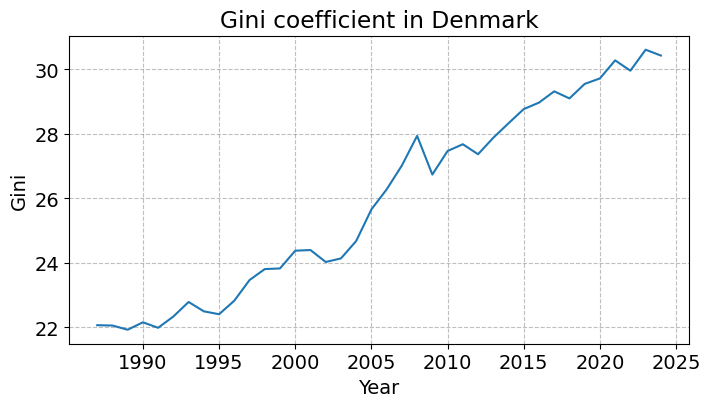

In [ ]:
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot()
ax.plot(ginidk.index,ginidk['gini'].astype(float))
ax.set_title('Gini coefficient in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Gini')

In [ ]:
IFOR32 = DstApi('IFOR32')
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [ ]:
params = {
    'table': 'IFOR32',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

df = IFOR32.get_data(params=params)
df.head(10)
df.tail(10)

,DECILGEN,KOMMUNEDK,TID,INDHOLD
370,First decil,All Denmark,2001,62629
371,Second decil,All Denmark,2001,98552
372,Third decil,All Denmark,2001,114430
373,Fourth decil,All Denmark,2001,129885
374,Fifth decil,All Denmark,2001,144273
375,Sixth decil,All Denmark,2001,158392
376,Seventh decil,All Denmark,2001,173884
377,Eigth decil,All Denmark,2001,193021
378,Ninth decil,All Denmark,2001,221638
379,Tenth decil,All Denmark,2001,338942


In [ ]:
df=df.drop(columns=['KOMMUNEDK'])
df = df.rename(columns={'INDHOLD':'income', 'TID': 'year'})
df= df.set_index('year').sort_index()

df.head(5)

,DECILGEN,income
year,,
1987,First decil,31418
1987,Ninth decil,123582
1987,Eigth decil,110184
1987,Seventh decil,100691
1987,Sixth decil,92777


<Axes: title={'center': 'Top 10% income share in Denmark'}, xlabel='Year', ylabel='Share of total income'>

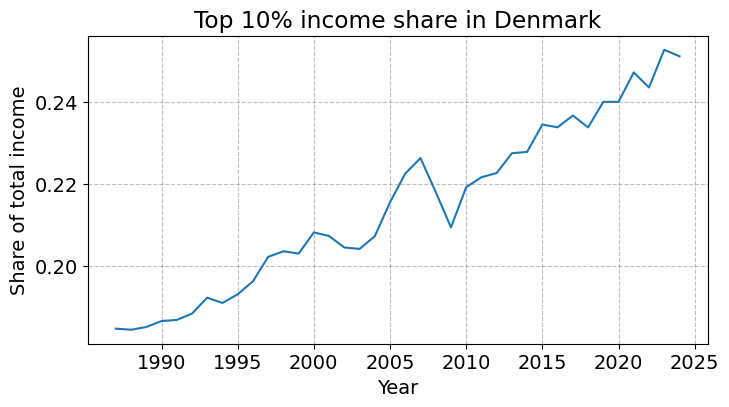

In [ ]:
pivot = df.pivot_table(values='income', index=df.index, columns='DECILGEN', aggfunc='sum')
top10_share = pivot['Tenth decil'] / pivot.sum(axis=1)

top10_share.plot(title='Top 10% income share in Denmark', ylabel='Share of total income', xlabel='Year', figsize=(8,4))

#Describe how inequality in Denmark has developed since 1987. Do the two measures
tell the same story? 

Both graphs show gradually increasing inequality from 1987 to 2000, a slight dip from 2000 to ~2003 followed by a sharp spike that peaked immediately before the financial crisis and sharply fell during it, before continuing on its previous trend of gradually increasing from 2010-2024.


In [ ]:
#Compute the correlation between them over time
np.corrcoef(ginidk['gini'].astype(float), top10_share)[0,1]





np.float64(0.9816415450527721)

### 1.2 Prediction

In [ ]:
# Importing the packages

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [ ]:
# Setting up the prediction

y= ginidk['gini'].astype(float).values
t = ginidk.index.astype(int).values - 1987
t = t.astype(float)

S1 = lambda beta: sum((y-(beta[0] + beta[1]*t))**2)
S2 = lambda beta: sum((y-(beta[0] + beta[1]*t+beta[2]*t**2))**2)


In [ ]:
# Solving the minimization problem

minproblin= minimize(S1, x0=(0,0), constraints=None)
minprobqua= minimize(S2, x0=(0,0,0), constraints=None)

beta0_lin, beta1_lin = minproblin.x
beta0_quad, beta1_quad, beta2_quad = minprobqua.x

print("beta linear=", beta0_lin, beta1_lin)
print("beta quadratic=", beta0_quad, beta1_quad, beta2_quad)

beta linear= 21.042753545648125 0.26354959467635763
beta quadratic= 21.304186697307134 0.21997579816762736 0.0011776761712922607


In [ ]:
# Checking the answes against np.polyfit

coeff_lin = np.polyfit(t,y,1)
print(coeff_lin)

coeff_quad= np.polyfit(t,y,2)
print(coeff_quad)

[ 0.26354962 21.04275304]
[1.17769085e-03 2.19975061e-01 2.13042004e+01]


In [ ]:
# Predicting and plotting the Gini coefficient in 2030 and 2040

t2030=2030-1987
t2040=2040-1987

"""
To find y, I set y to the formula S1 and S2 because the difference between them should be 0 if the formula is correctly minimized.
"""
lin_gin2030 = beta1 + beta1*t2030
lin_gin2040 = beta1 + beta1*t2040
quad_gin2030= beta2 + beta2*t2030+beta2*t2030**2
quad_gin2040= beta2 + beta2*t2040+beta2*t2040**2

#Plotting
plt.scatter(2030, lin_gin2030, color='blue')
plt.text(2030 + 0.5, lin_gin2030 + 0.001, '2030 (linear)', fontsize=9)

plt.scatter(2040, lin_gin2040, color='blue')
plt.text(2040 + 0.5, lin_gin2040 + 0.001, '2040 (linear)', fontsize=9)

plt.scatter(2030, quad_gin2030, color='red')
plt.text(2030 + 0.5, quad_gin2030 + 0.001, '2030 (quadratic)', fontsize=9)

plt.scatter(2040, quad_gin2040, color='red')
plt.text(2040 + 0.5, quad_gin2040 + 0.001, '2040 (quadratic)', fontsize=9)

plt.title('Gini predictions')
plt.xlabel('Year')
plt.ylabel('Gini')

NameError: name 'beta1' is not defined

Explaining the graph:
...

### 1.3 Municipalities

In [ ]:
"""
Gini across municipalities
"""
params_muni_gini = {
    'table': 'IFOR41',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

municip_gini = IFOR41.get_data(params=params_muni_gini)

municip_gini = municip_gini.rename(columns={'INDHOLD':'gini', 'TID': 'year'})
municip_gini= municip_gini.set_index('year').sort_index()

<Axes: title={'center': 'Top 10% income share in Denmark'}, xlabel='Year', ylabel='Share of total income'>

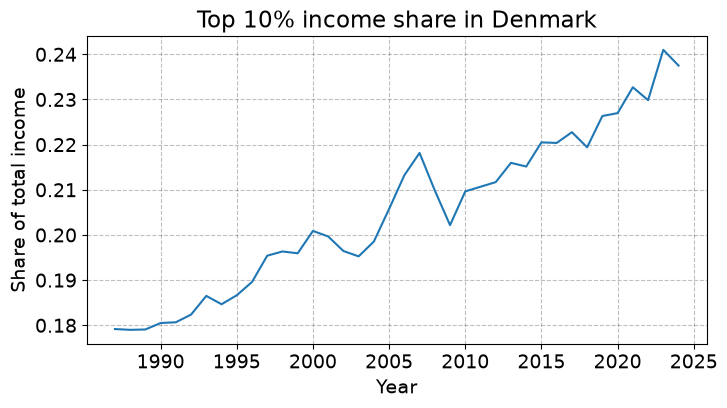

In [ ]:
"""
Top 10 share across municipalities.
"""
params_muni_top10 = {
    'table': 'IFOR32',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

municip_top10 = IFOR32.get_data(params=params_muni_top10)

municip_top10 = municip_top10.rename(columns={'INDHOLD':'income', 'TID': 'year'})
municip_top10= municip_top10.set_index('year').sort_index()

muni_pivot = municip_top10.pivot_table(values='income', index=municip_top10.index, columns='DECILGEN', aggfunc='sum')
muni_top10_share = muni_pivot['Tenth decil'] / muni_pivot.sum(axis=1)

muni_top10_share.plot(title='Top 10% income share in Denmark', ylabel='Share of total income', xlabel='Year', figsize=(8,4))

In [ ]:
#The correlation across municipalities

np.corrcoef(municip_gini['gini'].astype(float), muni_top10_share)[0,1]

Compute the correlation between the Gini coefficient and the top 10 percent
share across municipalities. Is it similar to the correlation over time you found
above?

...

#### 1.3.2

In [ ]:
#Sorting gini for 2024
gini_2024 = municip_gini.loc[2024].sort_values('gini')

#Finding the smallest and largest gini coefficients
smallest_gini = gini_2024[['KOMMUNEDK', 'gini']].head(10)
largest_gini = gini_2024[['KOMMUNEDK', 'gini']].tail(10)

print("10 most equal municipalities: ", smallest_gini)
print("10 most unequal municipalities: ", largest_gini)

10 most equal municipalities:              KOMMUNEDK   gini
year                        
2024  Faaborg-Midtfyn  23.77
2024           Egedal  23.85
2024         Bornholm  24.03
2024             Faxe  24.09
2024         Favrskov  24.41
2024          Halsnæs  24.41
2024           Assens  24.46
2024        Hedensted  24.58
2024      Albertslund  24.66
2024            Odder  24.70
10 most unequal municipalities:             KOMMUNEDK   gini
year                       
2024       Helsingør  30.55
2024     Fredensborg  32.76
2024          Aarhus  33.43
2024      Copenhagen  34.97
2024   Frederiksberg  36.54
2024  Lyngby-Taarbæk  39.28
2024        Hørsholm  40.07
2024           Vejen  46.32
2024       Rudersdal  47.31
2024        Gentofte  49.04


#### 1.3.3

In [ ]:
gini_2024 = municip_gini[municip_gini['year'] == 2024][['KOMMUNEDK', 'gini']].rename(columns={'gini': 'gini_2024'})
gini_1987 = municip_gini[municip_gini['year'] == 1987][['KOMMUNEDK', 'gini']].rename(columns={'gini': 'gini_1987'})

gini_change = gini_2024.merge(gini_1987, on='KOMMUNEDK', how='inner')


gini_change['gini_change'] = gini_change['gini_2024'].astype(float) - gini_change['gini_1987'].astype(float)

gini_change_sorted = gini_change.sort_values('gini_change', ascending=False)


# Biggest change
print("Biggest change in Gini: ", gini_change_sorted.head(10))

# Smallest change
print("Smallest change in Gini", gini_change.sort_values('gini_change', ascending=True).head(10))

Biggest change in Gini:           KOMMUNEDK gini_2024 gini_1987  gini_change
23           Vejen     46.32     21.20        25.12
63       Rudersdal     47.31     29.05        18.26
49        Gentofte     49.04     31.10        17.94
51  Lyngby-Taarbæk     39.28     24.97        14.31
29      Copenhagen     34.97     23.05        11.92
31        Hørsholm     40.07     28.39        11.68
58     Fredensborg     32.76     21.17        11.59
96          Aarhus     33.43     22.10        11.33
62   Frederiksberg     36.54     25.28        11.26
55      Vallensbæk     26.70     15.90        10.80
Smallest change in Gini           KOMMUNEDK gini_2024 gini_1987  gini_change
5              Fanø     26.34     25.67         0.67
27              Ærø     26.98     24.63         2.35
40             Faxe     24.09     21.64         2.45
67             Læsø     25.41     22.81         2.60
81         Bornholm     24.03     21.31         2.72
84  Faaborg-Midtfyn     23.77     20.88         2.89
75      

### 1.4 Extension

In [ ]:
AULP01 = DstApi('AULP01') 

AULP01.tablesummary(language='en')

Table AULP01: Full-time unemployed persons in per cent of the labour force by region, age, sex and time
Last update: 2026-04-14T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,OMRÅDE,117,000,All Denmark,997,Abroad,False
1,ALDER,10,TOT,"Age, total",6099,60 year and over,False
2,KØN,3,TOT,Total,K,Women,False
3,Tid,19,2007,2007,2025,2025,True


In [ ]:
params = {
    'table': 'AULP01',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'OMRÅDE', 'values': ['*']},
        {'code': 'ALDER', 'values': ['TOT']},
        {'code': 'KØN', 'values': ['TOT']}, 
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

unemployment = AULP01.get_data(params=params)
unemployment.head(5)

,OMRÅDE,ALDER,KØN,TID,INDHOLD
0,All Denmark,"Age, total",Total,2013,5.8
1,Province Byen København,"Age, total",Total,2013,6.9
2,Province Københavns omegn,"Age, total",Total,2013,5.9
3,Province Nordsjælland,"Age, total",Total,2013,4.4
4,Province Bornholm,"Age, total",Total,2013,7.0


In [ ]:
unemployment=unemployment.drop(columns=['ALDER','KØN'])
unemployment = unemployment.rename(columns={'INDHOLD':'unemployment', 'OMRÅDE': 'municipality', 'TID': 'year'})
unemployment= unemployment.set_index('year').sort_index()

display(unemployment)

,municipality,unemployment
year,,
2007,Faaborg-Midtfyn,3.6
2007,Slagelse,4.6
2007,Stevns,3.3
2007,Sorø,3.0
2007,Lejre,1.9
...,...,...
2025,Hvidovre,2.8
2025,Høje-Taastrup,3.8
2025,Lyngby-Taarbæk,2.4


In [ ]:
drop_rows = unemployment.municipality.str.contains('Region')
drop_rows  |= unemployment.municipality.str.contains('Province')
drop_rows |= unemployment.municipality.str.contains('All Denmark')
unemployment.loc[~drop_rows,:].iloc[:5,:5]

,municipality,unemployment
year,,
2007,Faaborg-Midtfyn,3.6
2007,Slagelse,4.6
2007,Stevns,3.3
2007,Sorø,3.0
2007,Lejre,1.9


In [ ]:
unemployment= unemployment.loc[drop_rows==False] # keep everything else
unemployment.iloc[:5,:5]

,municipality,unemployment
year,,
2007,Faaborg-Midtfyn,3.6
2007,Slagelse,4.6
2007,Stevns,3.3
2007,Sorø,3.0
2007,Lejre,1.9


In [ ]:
unemployment = unemployment.reset_index().sort_values(['year','municipality']).reset_index(drop=True) # drop=True to avoid adding old index as a column
unemployment.iloc[:5,:5]

,year,municipality,unemployment
0,2007,Aabenraa,3.8
1,2007,Aalborg,5.1
2,2007,Aarhus,3.9
3,2007,Albertslund,4.8
4,2007,Allerød,1.6


<h2> 2 Simulating the income distribution

### 2.1 The model

In [ ]:
import pickle
import numpy as np

from scipy.stats import norm 

In [ ]:
from income_simulation import simulate_income_distribution
from Gini import gini


N=50000
p_e=(0.4,0.35,0.25)
s_e=(1,3,5)
h_e0=(1.00,1.20,1.55)
delta_e=(0.010,0.020,0.030)
delta=(0.06)
sigma_psi=0.1
lambda_psi=0.6
sigma=0.05
y_su=0.45
rho=0.60
y_floor=0.35
age_min=18
age_max=65
seed=123

result = simulate_income_distribution(N, p_e, s_e, h_e0, delta_e, delta, sigma_psi,
                                      lam, sigma, y_su, rho, y_floor,
                                       age_min, age_max, seed)

ages = result['ages']
income = result['income']      
employed = result['employed']
e = result['education']

#Check that the mean is one for the lognormal shock psi
rng_check = np.random.default_rng(seed)
psi_check = rng_check.lognormal(-0.5 * sigma_psi**2, sigma_psi, size=1_000_000)

print(f'Mean of psi: {psi_check.mean():.4f}')  # should be equal or close to 1.0000

### 2.2 Simulate the income distribution

In [ ]:

# Mean and selected percentiles of income over the life cycle

percentiles = [10, 25, 50, 75, 90]
income_percentiles = np.percentile(income, percentiles, axis=0)  # shape (5, T)
income_mean = income.mean(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ages, income_mean, label='Mean', linewidth=2, color='black')
for p, series in zip(percentiles, income_percentiles):
    ax.plot(ages, series, label=f'p{p}', linestyle='--')
ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_title('Income over the life cycle')
ax.legend()

# Histograms of the income distribution at selected ages
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, age in zip(axes, [25, 35, 45, 60]):
    idx = age - age_min  # column index for this age
    ax.hist(income[:, idx], bins=50)
    ax.set_title(f'Age {age}')
    ax.set_xlabel('Income')
axes[0].set_ylabel('Count')
fig.tight_layout()


### 2.3 Compute the Gini coefficient

### 2.4 What drives inequality?

### 2.5 Extension: more risk